In [1]:
from pathlib import Path

search_folder = Path("dog_search_abs")

import pandas as pd
import numpy as np
import pickle
import re


def get_file_index(file_path):
    return list(map(int, re.findall(r'\d+', str(file_path))))

def read_file(file_path):
    with open(file_path, "rb") as f:
        search_dict = pickle.load(f)
    
    return search_dict

# Build the search array results

search_array = np.empty((3, 3, 63), dtype=object)
# Build an array of shape: 3, 3, 63
# of dict with baseline & layers df

for file in search_folder.iterdir():
    # raw_index shape is: layer[1-64], in, out
    raw_index = get_file_index(file)
    # index shape is: in, out, layer[0-63]
    index = raw_index[1], raw_index[2], raw_index[0] - 1
    search_array[index] = read_file(file)

# Check for missing entries
missing_mask = (search_array == None)
if missing_mask.sum() > 0:
    print("Missing files")
    print(np.where(missing_mask))

def select_max_score(entry):
    return entry["search_df"]["score"].max()

def select_real_score(entry):
    return entry["search_df"]["score"].max() + entry["baseline"]

def select_baseline(entry):
    return entry["baseline"]

def get_sigma_select(sigma):
    def select_sigma(entry):
        best_line_idx = entry["search_df"]["score"].idxmax()
        best_line = entry["search_df"].iloc[best_line_idx]
        return best_line[sigma]
    return select_sigma

best_results_array = np.vectorize(select_max_score)(search_array)
best_correlations_array = np.vectorize(select_real_score)(search_array)
baseline_array = np.vectorize(select_baseline)(search_array)
best_s1_array = np.vectorize(get_sigma_select("s1"))(search_array)
best_s2_array = np.vectorize(get_sigma_select("s2"))(search_array)
incorrect_mask = best_s2_array - best_s1_array < 0
print(incorrect_mask.sum())

0


In [2]:
flat_s1 = best_s1_array.flatten()
flat_s2 = best_s2_array.flatten()
weights = abs(best_results_array.flatten())

In [3]:
X = np.array(list(zip(flat_s1, flat_s2)))

In [4]:
(weights < 0).sum() 

np.int64(0)

In [40]:
from sklearn.cluster import KMeans


kmeans = KMeans(n_clusters=7, n_init=10, random_state=0, max_iter=1000)
wt_kmeansclus = kmeans.fit(X, sample_weight = weights)
predicted_kmeans = kmeans.predict(X)


Change influence based on y layer, the further the more important it is?
Since near layer already have good correlation, they will have lower improvements and then lower influence

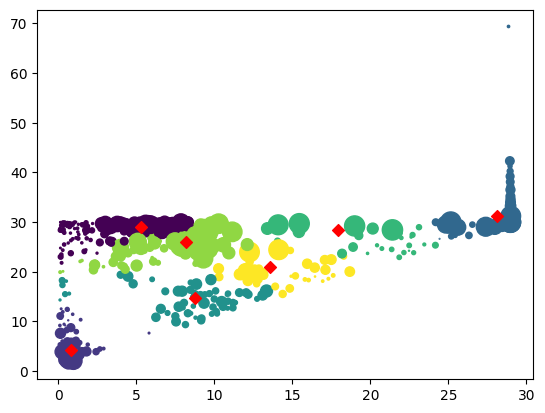

In [41]:
import matplotlib.pyplot as plt 

fig, ax = plt.subplots(nrows=1, ncols=1) 
p = plt.scatter(flat_s1, flat_s2, s=weights * 2000, c=predicted_kmeans)
plt.scatter([x for x,y in kmeans.cluster_centers_], [y for x,y in kmeans.cluster_centers_], color="red", marker="D")

In [26]:
kmeans.cluster_centers_

array([[ 5.31081941, 29.09173159],
       [ 0.78332135,  4.20696016],
       [28.09770555, 31.25821998],
       [ 8.75652767, 14.70467116],
       [17.91757676, 28.35390115],
       [ 8.1589559 , 25.99589687],
       [13.58994141, 20.95272641]])

In [ ]:
###### fig, ax = plt.subplots(nrows=1, ncols=1) 
p = plt.scatter(flat_s1, flat_s2, s=weights * 2000, c=weights)
plt.colorbar(p, ax=ax,orientation='vertical',label='influence')
plt.scatter([x for x,y in kmeans.cluster_centers_], [y for x,y in kmeans.cluster_centers_], color="black")

In [19]:
import numpy as np
from space_exploration.beans.dataset_bean import Dataset
from space_exploration.dataset.transforms.AllTransforms import TransformationReferences
dataset_name = "re200-sr1etot"
dataset = Dataset.get_dataset_or_fail(dataset_name)
# ds = dataset.get_training_dataset(64, TransformationReferences.DEFAULT_UNCHANGED.transformation, TransformationReferences.DEFAULT_UNCHANGED.transformation, size=1000)
ds = dataset.get_training_dataset(64, TransformationReferences.COMPONENT_NORMALIZE.transformation, TransformationReferences.Y_ALONG_COMPONENT_NORMALIZE.transformation, size=1000)
xs = np.array([x.numpy() for x, y in ds])
ys = np.array([y.numpy() for x, y in ds])

import torch
import torch.nn.functional as F
from scipy.stats import pearsonr

def get_gaussian_kernel2d(kernel_size=5, sigma=1.0, device='cpu'):
    coords = torch.arange(kernel_size, dtype=torch.float32, device=device) - kernel_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g /= g.sum()
    g2d = g[:, None] * g[None, :]  # outer product for 2D kernel
    g2d = g2d.unsqueeze(0).unsqueeze(0)  # shape (1,1,k,k)
    return g2d

def apply_dog_2d(images, sigma1=1.0, sigma2=2.0, kernel_size=9):
    """
    ys: torch.Tensor of shape (B, C, H, W)
    returns: DoG-filtered tensor, same shape
    """
    B, C, H, W = images.shape
    device = images.device
    
    # Get both Gaussian kernels
    g1 = get_gaussian_kernel2d(kernel_size, sigma1, device=device)
    g2 = get_gaussian_kernel2d(kernel_size, sigma2, device=device)
    
    # Depthwise convolution for both sigmas
    blurred1 = F.conv2d(images, g1, padding="same")
    blurred2 = F.conv2d(images, g2, padding="same")

    # Difference of Gaussians
    return blurred1 - blurred2

def get_correlation(x, y, s1, s2):
        # x: B, 1, 64, 64
        # y : B, 1, 64, 64
        x = torch.tensor(x, device="cuda")
        dog = apply_dog_2d(x, sigma1=s1, sigma2=s2, kernel_size=63).cpu()
        correlations = [pearsonr(dog[i].ravel(), y[i].ravel())[0] for i in range(dog.shape[0])]
        return abs(np.mean(correlations))

from tqdm import trange

def compute_correlations(tested_sigmas):
    correlations = np.zeros((3, 3, len(tested_sigmas), 63))

    for layer in trange(1, 63):
        for in_comp in range(3):
            for out_comp in range(3):
                for i, (s1, s2) in enumerate(tested_sigmas):
                
                    correlations[in_comp, out_comp, i, layer - 1] = get_correlation(xs[:, in_comp:in_comp+1, :, 0, :], ys[:, out_comp:out_comp+1, :, layer, :], s1, s2)
            
    return correlations

Loading std & mean of dataset re200-sr1etot
Loading stds & means of dataset re200-sr1etot
⌛ Initializing Dataset...
X...
[########################################] | 100% Completed | 434.60 ms
Y...
[########################################] | 100% Completed | 5.64 ss


In [20]:
corr_7 = compute_correlations(kmeans.cluster_centers_)

100%|███████████████████████████████████████████| 62/62 [20:26<00:00, 19.78s/it]


In [81]:
def get_corr_score(corr):
    return corr.max(2) - best_results_array

In [83]:
score_7 = get_corr_score(corr_7)

In [90]:
best_results_array.shape

(3, 3, 63)

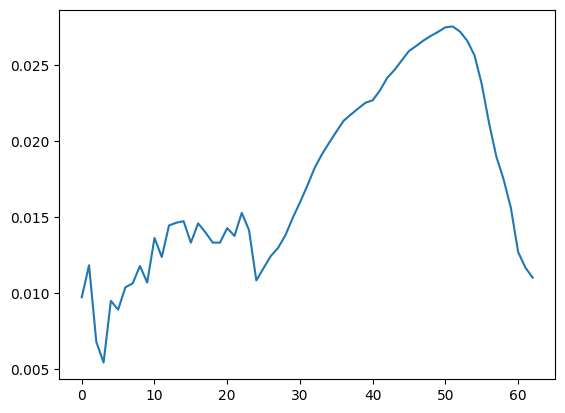

In [92]:
plt.plot(best_results_array.mean((0, 1)))

In [47]:
from pathlib import Path

save_folder = Path("clustering_data")
save_folder.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import pickle
import re


from sklearn.cluster import KMeans

def compute_kmeans_scores(cluster_amounts):

    for cluster_amount in cluster_amounts:
    
        kmeans = KMeans(n_clusters=cluster_amount, n_init=10, random_state=0, max_iter=1000)
        wt_kmeansclus = kmeans.fit(X, sample_weight = weights)
        predicted_kmeans = kmeans.predict(X)
    
        corr = compute_correlations(kmeans.cluster_centers_)

        kmeans_data = {}

        kmeans_data["correlations"] = corr
        kmeans_data["clusters"] = kmeans.cluster_centers_
        kmeans_data["kmeans"] = predicted_kmeans
        
        with open(save_folder / f"{cluster_amount}.pkl", "wb") as file:
            pickle.dump(kmeans_data, file)
    
    

In [84]:
compute_kmeans_scores([2])

  0%|                                                    | 0/62 [00:01<?, ?it/s]


KeyboardInterrupt: 

In [94]:

kmeans_search = {}
for file in save_folder.iterdir():
    try:
        kmean_name = re.search(r'/(.*?).pkl', str(file)).group(1)
        with open(file, "rb") as f:
            kmeans_search[kmean_name] = pickle.load(f)
    except AttributeError:
        pass
    


In [76]:
kmeans_search.keys()

dict_keys(['2', '1'])

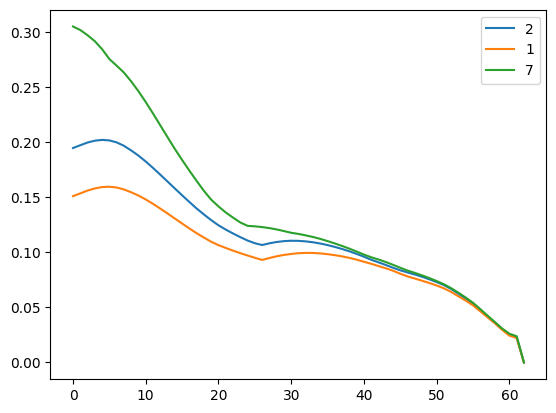

In [88]:
for key in kmeans_search.keys():
    plt.plot(kmeans_search[key]["correlations"].max(2).mean((0, 1)), label=key)
plt.plot(corr_7.max(2).mean((0, 1)), label="7")
plt.legend()

In [55]:
kmeans_1["clusters"]

array([[12.05568897, 25.32069688]])